In [1]:
%pip install bert-score
%pip install nltk

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 6.7 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 6.6 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 6.3 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 6.2 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.1 MB 6.1 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.8 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------ --------------------- 1.0/2.2 MB 6.3 MB/s eta 0:00:01
   ------------------------------------- -- 2.1/2.2 MB 5.6 MB

In [1]:
import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score

# === Load Translated Data ===
with open(r"C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_MBART-50_translated.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# === Collect Original and Back-Translated Sentences ===
originals = []
back_translations = []

for entry in data.values():
    original = entry.get("tweet", "").strip()
    back_translated = entry.get("translated_back_en", "").strip()

    if original and back_translated:
        originals.append(original)
        back_translations.append(back_translated)

# === BLEU Evaluation ===
smoothie = SmoothingFunction().method4
bleu_scores = [
    sentence_bleu([ref.split()], hyp.split(), smoothing_function=smoothie)
    for ref, hyp in zip(originals, back_translations)
]
average_bleu = sum(bleu_scores) / len(bleu_scores)

# === BERTScore Evaluation ===
P, R, F1 = score(back_translations, originals, lang="en", verbose=True)
average_bertscore = F1.mean().item()

# === Print Results ===
print(f"🔵 Average BLEU Score: {average_bleu:.4f}")
print(f"🟣 Average BERTScore F1: {average_bertscore:.4f}")


c:\Users\pauli\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\pauli\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pauli\.cache\huggingface\hub\models--roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article:

calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:25<00:00, 25.30s/it]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00,  4.98it/s]


done in 25.53 seconds, 0.78 sentences/sec
🔵 Average BLEU Score: 0.3528
🟣 Average BERTScore F1: 0.9412


In [9]:
import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score
import csv
import nltk
nltk.download('punkt')

# === File info ===
file_path = r"C:\Users\pauli\Downloads\deepl_translated_till_110.json"
model_name = "DeepL"

# === Load DeepL JSON ===
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

originals = []
translations = []

# === Extract pairs for evaluation ===
for entry in data.values():
    orig = entry.get("tweet", "").strip()
    back = entry.get("translated_back_en", "").strip()
    if orig and back:
        originals.append(orig)
        translations.append(back)

# === BLEU Calculation ===
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4
bleu_scores = [
    sentence_bleu([ref.split()], hyp.split(), smoothing_function=smoothie)
    for ref, hyp in zip(originals, translations)
]
avg_bleu = sum(bleu_scores) / len(bleu_scores)

# === BERTScore Calculation ===
from bert_score import score
P, R, F1 = score(translations, originals, lang="en", verbose=True)
avg_bertscore = F1.mean().item()

# === Output Results ===
print(f"📊 Evaluation for {model_name}")
print(f"🔵 Average BLEU: {avg_bleu:.4f}")
print(f"🟣 Average BERTScore F1: {avg_bertscore:.4f}")

# === Save per-sample scores to CSV ===
output_csv = file_path.replace(".json", f"_{model_name}_scores.csv")
with open(output_csv, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Index", "BLEU", "BERTScore"])
    for i, (b, bert) in enumerate(zip(bleu_scores, F1.tolist())):
        writer.writerow([i, b, bert])

print(f" Per-sample scores saved to:\n{output_csv}")


c:\Users\pauli\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pauli\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


: 

In [1]:
import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import csv

# === File info ===
file_path = r"C:\Users\pauli\Downloads\deepl_translated_till_110.json"
model_name = "DeepL"

# === Load the file ===
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

originals = []
translations = []

# === Extract the original and back-translated sentences ===
for entry in data.values():
    orig = entry.get("tweet", "").strip()
    back = entry.get("translated_back_en", "").strip()
    if orig and back:
        originals.append(orig)
        translations.append(back)

# === BLEU calculation setup ===
smoothie = SmoothingFunction().method4

bleu_scores = []
for ref, hyp in zip(originals, translations):
    # Each reference must be a list of tokens (inside a list for multiple refs)
    reference = [ref.split()]
    hypothesis = hyp.split()
    score = sentence_bleu(reference, hypothesis, smoothing_function=smoothie)
    bleu_scores.append(score)

avg_bleu = sum(bleu_scores) / len(bleu_scores)

print(f"✅ Average BLEU score for {model_name}: {avg_bleu:.4f}")

# === Save per-sample BLEU scores to CSV ===
output_csv = file_path.replace(".json", f"_{model_name}_BLEU_scores.csv")
with open(output_csv, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Index", "BLEU"])
    for i, bscore in enumerate(bleu_scores):
        writer.writerow([i, bscore])

print(f"📄 BLEU scores saved to: {output_csv}")


✅ Average BLEU score for DeepL: 0.5442
📄 BLEU scores saved to: C:\Users\pauli\Downloads\deepl_translated_till_110_DeepL_BLEU_scores.csv


In [2]:
import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import csv

# === File info ===
file_path = r"C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_translated_deepl.json"
model_name = "DeepL"

# === Load the file ===
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

originals = []
translations = []

# === Extract the original and back-translated sentences ===
for entry in data.values():
    orig = entry.get("tweet", "").strip()
    back = entry.get("translated_back_en", "").strip()
    if orig and back:
        originals.append(orig)
        translations.append(back)

# === BLEU calculation setup ===
smoothie = SmoothingFunction().method4

bleu_scores = []
for ref, hyp in zip(originals, translations):
    # Each reference must be a list of tokens (inside a list for multiple refs)
    reference = [ref.split()]
    hypothesis = hyp.split()
    score = sentence_bleu(reference, hypothesis, smoothing_function=smoothie)
    bleu_scores.append(score)

avg_bleu = sum(bleu_scores) / len(bleu_scores)

print(f"✅ Average BLEU score for {model_name}: {avg_bleu:.4f}")

# === Save per-sample BLEU scores to CSV ===
output_csv = file_path.replace(".json", f"_{model_name}_BLEU_scores.csv")
with open(output_csv, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Index", "BLEU"])
    for i, bscore in enumerate(bleu_scores):
        writer.writerow([i, bscore])

print(f"📄 BLEU scores saved to: {output_csv}")


✅ Average BLEU score for DeepL: 0.5458
📄 BLEU scores saved to: C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_translated_deepl_DeepL_BLEU_scores.csv


In [ ]:
#google translate


import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import csv

# === File info ===
file_path = r"C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_translated_google.json"
model_name = "DeepL"

# === Load the file ===
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

originals = []
translations = []

# === Extract the original and back-translated sentences ===
for entry in data.values():
    orig = entry.get("tweet", "").strip()
    back = entry.get("translated_back_en", "").strip()
    if orig and back:
        originals.append(orig)
        translations.append(back)

# === BLEU calculation setup ===
smoothie = SmoothingFunction().method4

bleu_scores = []
for ref, hyp in zip(originals, translations):
    # Each reference must be a list of tokens (inside a list for multiple refs)
    reference = [ref.split()]
    hypothesis = hyp.split()
    score = sentence_bleu(reference, hypothesis, smoothing_function=smoothie)
    bleu_scores.append(score)

avg_bleu = sum(bleu_scores) / len(bleu_scores)

print(f"✅ Average BLEU score for {model_name}: {avg_bleu:.4f}")

# === Save per-sample BLEU scores to CSV ===
output_csv = file_path.replace(".json", f"_{model_name}_BLEU_scores.csv")
with open(output_csv, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Index", "BLEU"])
    for i, bscore in enumerate(bleu_scores):
        writer.writerow([i, bscore])

print(f"📄 BLEU scores saved to: {output_csv}")


✅ Average BLEU score for DeepL: 0.2440
📄 BLEU scores saved to: C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_translated_google_DeepL_BLEU_scores.csv


In [4]:
#nllb-200-distilled-600M


import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import csv

# === File info ===
file_path = r"C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_translated.json"
model_name = "DeepL"

# === Load the file ===
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

originals = []
translations = []

# === Extract the original and back-translated sentences ===
for entry in data.values():
    orig = entry.get("tweet", "").strip()
    back = entry.get("translated_back_en", "").strip()
    if orig and back:
        originals.append(orig)
        translations.append(back)

# === BLEU calculation setup ===
smoothie = SmoothingFunction().method4

bleu_scores = []
for ref, hyp in zip(originals, translations):
    # Each reference must be a list of tokens (inside a list for multiple refs)
    reference = [ref.split()]
    hypothesis = hyp.split()
    score = sentence_bleu(reference, hypothesis, smoothing_function=smoothie)
    bleu_scores.append(score)

avg_bleu = sum(bleu_scores) / len(bleu_scores)

print(f"✅ Average BLEU score for {model_name}: {avg_bleu:.4f}")

# === Save per-sample BLEU scores to CSV ===
output_csv = file_path.replace(".json", f"_{model_name}_BLEU_scores.csv")
with open(output_csv, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Index", "BLEU"])
    for i, bscore in enumerate(bleu_scores):
        writer.writerow([i, bscore])

print(f"📄 BLEU scores saved to: {output_csv}")


✅ Average BLEU score for DeepL: 0.3528
📄 BLEU scores saved to: C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_translated_DeepL_BLEU_scores.csv


In [5]:
#MBART-50


import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import csv

# === File info ===
file_path = r"C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_MBART-50_translated.json"
model_name = "DeepL"

# === Load the file ===
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

originals = []
translations = []

# === Extract the original and back-translated sentences ===
for entry in data.values():
    orig = entry.get("tweet", "").strip()
    back = entry.get("translated_back_en", "").strip()
    if orig and back:
        originals.append(orig)
        translations.append(back)

# === BLEU calculation setup ===
smoothie = SmoothingFunction().method4

bleu_scores = []
for ref, hyp in zip(originals, translations):
    # Each reference must be a list of tokens (inside a list for multiple refs)
    reference = [ref.split()]
    hypothesis = hyp.split()
    score = sentence_bleu(reference, hypothesis, smoothing_function=smoothie)
    bleu_scores.append(score)

avg_bleu = sum(bleu_scores) / len(bleu_scores)

print(f"✅ Average BLEU score for {model_name}: {avg_bleu:.4f}")

# === Save per-sample BLEU scores to CSV ===
output_csv = file_path.replace(".json", f"_{model_name}_BLEU_scores.csv")
with open(output_csv, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Index", "BLEU"])
    for i, bscore in enumerate(bleu_scores):
        writer.writerow([i, bscore])

print(f"📄 BLEU scores saved to: {output_csv}")


✅ Average BLEU score for DeepL: 0.2753
📄 BLEU scores saved to: C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_MBART-50_translated_DeepL_BLEU_scores.csv


In [8]:
#m2m100_1.2B


import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import csv

# === File info ===
file_path = r"C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_M2M100_translated.json"
model_name = "DeepL"

# === Load the file ===
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

originals = []
translations = []

# === Extract the original and back-translated sentences ===
for entry in data.values():
    orig = entry.get("tweet", "").strip()
    back = entry.get("translated_back_en", "").strip()
    if orig and back:
        originals.append(orig)
        translations.append(back)

# === BLEU calculation setup ===
smoothie = SmoothingFunction().method4

bleu_scores = []
for ref, hyp in zip(originals, translations):
    # Each reference must be a list of tokens (inside a list for multiple refs)
    reference = [ref.split()]
    hypothesis = hyp.split()
    score = sentence_bleu(reference, hypothesis, smoothing_function=smoothie)
    bleu_scores.append(score)

avg_bleu = sum(bleu_scores) / len(bleu_scores)

print(f"✅ Average BLEU score for {model_name}: {avg_bleu:.4f}")

# === Save per-sample BLEU scores to CSV ===
output_csv = file_path.replace(".json", f"_{model_name}_BLEU_scores.csv")
with open(output_csv, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Index", "BLEU"])
    for i, bscore in enumerate(bleu_scores):
        writer.writerow([i, bscore])

print(f"📄 BLEU scores saved to: {output_csv}")


✅ Average BLEU score for DeepL: 0.3709
📄 BLEU scores saved to: C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_M2M100_translated_DeepL_BLEU_scores.csv


In [1]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


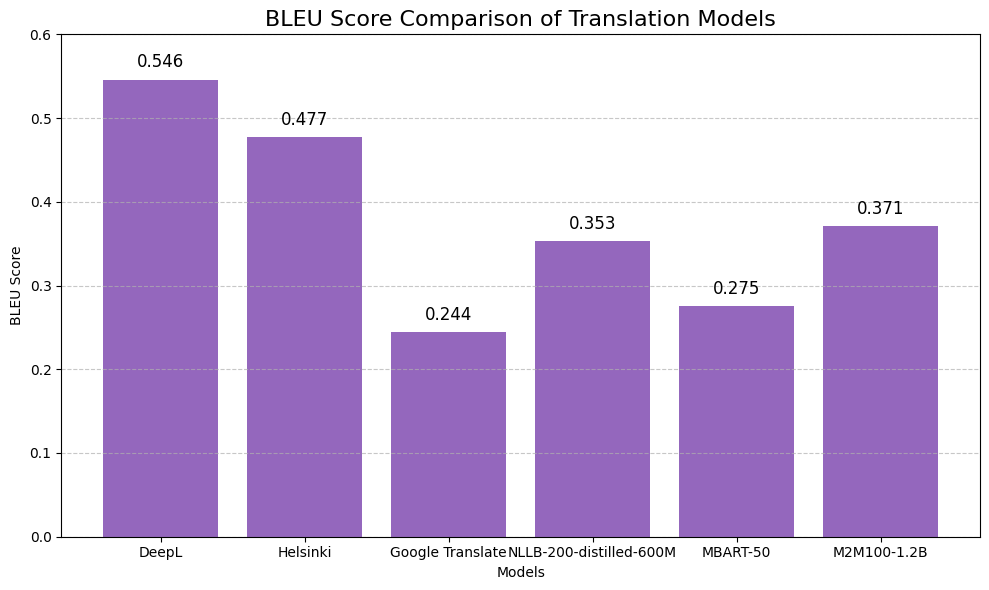

In [5]:

import matplotlib.pyplot as plt

# Model names and their BLEU scores
models = [
    "DeepL",
    "Helsinki",
    "Google Translate",
    "NLLB-200-distilled-600M",
    "MBART-50",
    "M2M100-1.2B"
]

bleu_scores = [0.5458, 0.4769, 0.2440, 0.3528, 0.2753, 0.3709]

# Purple color hex code
purple = '#9467bd'

# Create bar chart
plt.figure(figsize=(10,6))
bars = plt.bar(models, bleu_scores, color=purple)

# Add score labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontsize=12)

plt.ylim(0, 0.6)
plt.title("BLEU Score Comparison of Translation Models", fontsize=16)
plt.ylabel("BLEU Score")
plt.xlabel("Models")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [6]:
#bertscore

%pip install bert-score


Note: you may need to restart the kernel to use updated packages.


In [ ]:
#deepl

import json
from bert_score import score

# Load JSON file
with open("C:/Users/pauli/Downloads/EXIST2025_filtered_5yes_first20_translated_deepl.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract references (original tweets) and candidates (back-translations)
references = []
candidates = []

for item in data.values():
    if "tweet" in item and "translated_back_en" in item:
        references.append(item["tweet"])
        candidates.append(item["translated_back_en"])


P, R, F1 = score(candidates, references, lang="en", model_type="distilbert-base-uncased",  # Lighter model
    verbose=True)

print(f"Average Precision: {P.mean().item():.4f}")
print(f"Average Recall: {R.mean().item():.4f}")
print(f"Average F1: {F1.mean().item():.4f}")


c:\Users\pauli\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pauli\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:05<00:00,  5.71s/it]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00,  5.24it/s]

done in 5.97 seconds, 3.35 sentences/sec
Average Precision: 0.9709
Average Recall: 0.9683
Average F1: 0.9696


In [17]:
#deepl

import json
from bert_score import score

# Load JSON file
with open(r"C:\Users\pauli\Downloads\deepl_translated_till_110.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract references (original tweets) and candidates (back-translations)
references = []
candidates = []

for item in data.values():
    if "tweet" in item and "translated_back_en" in item:
        references.append(item["tweet"])
        candidates.append(item["translated_back_en"])

# Calculate BERTScore
P, R, F1 = score(candidates, references, lang="en", model_type="distilbert-base-uncased",  # Lighter model
    verbose=True)

# Print average scores
print(f"Average Precision: {P.mean().item():.4f}")
print(f"Average Recall: {R.mean().item():.4f}")
print(f"Average F1: {F1.mean().item():.4f}")


calculating scores...
computing bert embedding.


100%|██████████| 4/4 [00:19<00:00,  4.93s/it]


computing greedy matching.


100%|██████████| 2/2 [00:00<00:00, 18.16it/s]

done in 19.88 seconds, 5.53 sentences/sec
Average Precision: 0.9638
Average Recall: 0.9626
Average F1: 0.9631


In [10]:
#google translate

import json
from bert_score import score

# Load JSON file
with open(r"C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_translated_google.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract references (original tweets) and candidates (back-translations)
references = []
candidates = []

for item in data.values():
    if "tweet" in item and "translated_back_en" in item:
        references.append(item["tweet"])
        candidates.append(item["translated_back_en"])

# Calculate BERTScore
P, R, F1 = score(candidates, references, lang="en", model_type="distilbert-base-uncased",  # Lighter model
    verbose=True)

# Print average scores
print(f"Average Precision: {P.mean().item():.4f}")
print(f"Average Recall: {R.mean().item():.4f}")
print(f"Average F1: {F1.mean().item():.4f}")


calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:04<00:00,  4.05s/it]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00, 17.45it/s]

done in 4.12 seconds, 4.86 sentences/sec
Average Precision: 0.9401
Average Recall: 0.9076
Average F1: 0.9228


In [11]:
#nllb-200-distilled-600M

import json
from bert_score import score

# Load JSON file
with open(r"C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_translated.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract references (original tweets) and candidates (back-translations)
references = []
candidates = []

for item in data.values():
    if "tweet" in item and "translated_back_en" in item:
        references.append(item["tweet"])
        candidates.append(item["translated_back_en"])

# Calculate BERTScore
P, R, F1 = score(candidates, references, lang="en", model_type="distilbert-base-uncased",  # Lighter model
    verbose=True)

# Print average scores
print(f"Average Precision: {P.mean().item():.4f}")
print(f"Average Recall: {R.mean().item():.4f}")
print(f"Average F1: {F1.mean().item():.4f}")


calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:05<00:00,  5.86s/it]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00,  8.75it/s]


done in 6.04 seconds, 3.31 sentences/sec
Average Precision: 0.9492
Average Recall: 0.8956
Average F1: 0.9200


In [12]:

#MBart50

import json
from bert_score import score

# Load JSON file
with open(r"C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_MBART-50_translated.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract references (original tweets) and candidates (back-translations)
references = []
candidates = []

for item in data.values():
    if "tweet" in item and "translated_back_en" in item:
        references.append(item["tweet"])
        candidates.append(item["translated_back_en"])

# Calculate BERTScore
P, R, F1 = score(candidates, references, lang="en", model_type="distilbert-base-uncased",  # Lighter model
    verbose=True)

# Print average scores
print(f"Average Precision: {P.mean().item():.4f}")
print(f"Average Recall: {R.mean().item():.4f}")
print(f"Average F1: {F1.mean().item():.4f}")


calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:04<00:00,  4.79s/it]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00, 19.80it/s]

done in 4.86 seconds, 4.12 sentences/sec
Average Precision: 0.9204
Average Recall: 0.8511
Average F1: 0.8824


In [13]:

#m2m100_1.2B

import json
from bert_score import score

# Load JSON file
with open(r"C:\Users\pauli\Downloads\EXIST2025_filtered_5yes_first20_M2M100_translated.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract references (original tweets) and candidates (back-translations)
references = []
candidates = []

for item in data.values():
    if "tweet" in item and "translated_back_en" in item:
        references.append(item["tweet"])
        candidates.append(item["translated_back_en"])

# Calculate BERTScore
P, R, F1 = score(candidates, references, lang="en", model_type="distilbert-base-uncased",  # Lighter model
    verbose=True)

# Print average scores
print(f"Average Precision: {P.mean().item():.4f}")
print(f"Average Recall: {R.mean().item():.4f}")
print(f"Average F1: {F1.mean().item():.4f}")


calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:03<00:00,  3.42s/it]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00, 45.58it/s]

done in 3.46 seconds, 5.79 sentences/sec
Average Precision: 0.9555
Average Recall: 0.9297
Average F1: 0.9418


In [3]:

#helsinki bert

import json
from bert_score import score

# Load JSON file
with open(r"C:\Users\pauli\Downloads\EXIST2025_translated_first110_helsinki.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract references (original tweets) and candidates (back-translations)
references = []
candidates = []

for item in data.values():
    if "tweet" in item and "translated_back_en" in item:
        references.append(item["tweet"])
        candidates.append(item["translated_back_en"])

# Calculate BERTScore
P, R, F1 = score(candidates, references, lang="en", model_type="distilbert-base-uncased",  # Lighter model
    verbose=True)

# Print average scores
print(f"Average Precision: {P.mean().item():.4f}")
print(f"Average Recall: {R.mean().item():.4f}")
print(f"Average F1: {F1.mean().item():.4f}")


c:\Users\pauli\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


calculating scores...
computing bert embedding.


100%|██████████| 4/4 [00:11<00:00,  2.79s/it]


computing greedy matching.


100%|██████████| 2/2 [00:00<00:00, 28.44it/s]

done in 11.25 seconds, 9.78 sentences/sec
Average Precision: 0.9609
Average Recall: 0.9536
Average F1: 0.9570


In [2]:
#helsinki bleu


import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import csv

# === File info ===
file_path = r"C:\Users\pauli\Downloads\EXIST2025_translated_first110_helsinki.json"
model_name = "Helsinki"

# === Load the file ===
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

originals = []
translations = []

# === Extract the original and back-translated sentences ===
for entry in data.values():
    orig = entry.get("tweet", "").strip()
    back = entry.get("translated_back_en", "").strip()
    if orig and back:
        originals.append(orig)
        translations.append(back)

# === BLEU calculation setup ===
smoothie = SmoothingFunction().method4

bleu_scores = []
for ref, hyp in zip(originals, translations):
    # Each reference must be a list of tokens (inside a list for multiple refs)
    reference = [ref.split()]
    hypothesis = hyp.split()
    score = sentence_bleu(reference, hypothesis, smoothing_function=smoothie)
    bleu_scores.append(score)

avg_bleu = sum(bleu_scores) / len(bleu_scores)

print(f"✅ Average BLEU score for {model_name}: {avg_bleu:.4f}")

# === Save per-sample BLEU scores to CSV ===
output_csv = file_path.replace(".json", f"_{model_name}_BLEU_scores.csv")
with open(output_csv, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Index", "BLEU"])
    for i, bscore in enumerate(bleu_scores):
        writer.writerow([i, bscore])

print(f"📄 BLEU scores saved to: {output_csv}")


✅ Average BLEU score for Helsinki: 0.4769
📄 BLEU scores saved to: C:\Users\pauli\Downloads\EXIST2025_translated_first110_helsinki_Helsinki_BLEU_scores.csv


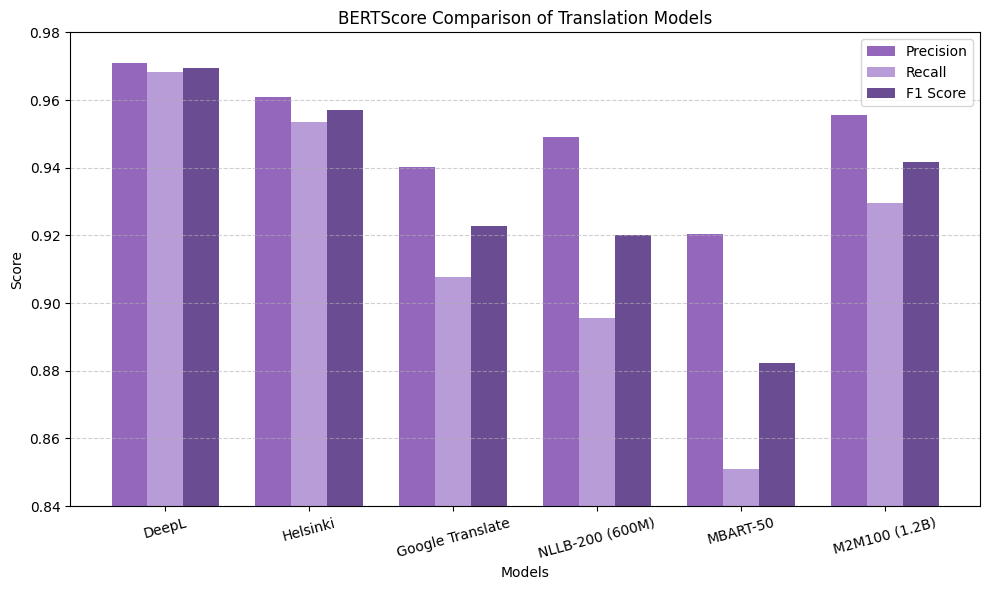

In [4]:
import matplotlib.pyplot as plt

# Translation systems and their BERTScore metrics
models = [
    "DeepL", 
    "Helsinki",
    "Google Translate", 
    "NLLB-200 (600M)", 
    "MBART-50", 
    "M2M100 (1.2B)"
]

precision = [0.9709, 0.9609,  0.9401, 0.9492, 0.9204, 0.9555]
recall = [0.9683, 0.9536, 0.9076, 0.8956, 0.8511, 0.9297]
f1 = [0.9696, 0.9570, 0.9228, 0.9200, 0.8824, 0.9418]

# Plotting setup
plt.figure(figsize=(10, 6))
bar_width = 0.25
x = range(len(models))

# Custom purple tones
precision_color = '#9467bd'       # Base purple
recall_color = '#b89cd8'          # Lighter purple
f1_color = '#6a4c93'              # Darker purple

# Bars for each metric
plt.bar([p - bar_width for p in x], precision, width=bar_width, label='Precision', color=precision_color)
plt.bar(x, recall, width=bar_width, label='Recall', color=recall_color)
plt.bar([p + bar_width for p in x], f1, width=bar_width, label='F1 Score', color=f1_color)

# Customize the plot
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("BERTScore Comparison of Translation Models")
plt.xticks(x, models, rotation=15)
plt.ylim(0.84, 0.98)
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Show plot
plt.show()
